### Imports

In [171]:
import pandas as pd
import numpy as np
import joblib
import os
import re

## Clasificador Bayesiano Naive

In [183]:
# Calculate class probabilities P(C)
def calculate_class_probabilities(y):
    classes, counts = np.unique(y, return_counts=True)
    class_probabilities = counts / y.shape[0]
    return dict(zip(classes, class_probabilities))

# Calculate conditional probabilities P(A|C)
def calculate_conditional_probabilities(X, y):
    classes = np.unique(y)
    conditional_probabilities = {}

    for c in classes: # Para cada clase
        X_cls = X[y == c] # Obtener los ejemplos de la clase
        cls_count = X_cls.shape[0] # Número de ejemplos en la clase

        # Aplicar la corrección de Laplace: sumar 1 al numerador y el número de posibles valores al denominador
        conditional_attributes = (X_cls.sum(axis=0) + 1) / (cls_count + 2)
        
        # Almacenar las probabilidades condicionales
        conditional_probabilities[c] = conditional_attributes

    return conditional_probabilities

# Classify a new example
def classify(x, class_probabilities, conditional_probabilities):
    """
    Calcula las probabilidades de cada clase para un nuevo ejemplo.
    
    Args:
    - x: Array de características del nuevo ejemplo (binario).
    - class_probabilities: Diccionario con probabilidades de clase.
    - conditional_probabilities: Diccionario con probabilidades condicionales para cada clase.

    Returns:
    - dict: Probabilidades de cada clase.
    """
    probabilities = {}
    
    for c, prob_cls in class_probabilities.items():
        probability = prob_cls
        for i, value in enumerate(x):
            cond_prob = conditional_probabilities[c][i]
            if value == 1:
                probability *= cond_prob
            else:
                probability *= (1 - cond_prob)
        probabilities[c] = probability
    
    # Normalizar para obtener probabilidades
    total_prob = sum(probabilities.values())
    for c in probabilities:
        probabilities[c] /= total_prob
    
    return probabilities

# UK Clasification

Consideremos el siguiente vector de atributos binarios: `(scones, cerveza, whisky, avena, fútbol)`.

El vector `x = (1, 0, 1, 1, 0)` significa que se trata de una persona que le gustan los scones, no toma cerveza, le gusta el whisky y la avena pero no ve futbol.

En el archivo `PreferenciasBritanicos.xlsx` se encuentran las preferencias de 6 personas inglesas y 7 personas escocesas.

In [173]:
# Load the data
data = pd.read_excel('PreferenciasBritanicos.xlsx')

# Split the data into features (X) and the target class (y)
X = data.iloc[:, :-1].values  # All attributes except nationality
y = data.iloc[:, -1].values   # Nationality

In [174]:
# Get class probabilities and conditional probabilities
class_probabilities = calculate_class_probabilities(y)
conditional_probabilities = calculate_conditional_probabilities(X, y)

# b) Classify example x1 = (1, 0, 1, 1, 0)
x1 = np.array([1, 0, 1, 1, 0])
result_x1 = classify(x1, class_probabilities, conditional_probabilities)

# c) Classify example x2 = (0, 1, 1, 0, 1)
x2 = np.array([0, 1, 1, 0, 1])
result_x2 = classify(x2, class_probabilities, conditional_probabilities)

print(f"The example x1 = {x1} is classified as: {result_x1}")
print(f"The example x2 = {x2} is classified as: {result_x2}")

The example x1 = [1 0 1 1 0] is classified as: E
The example x2 = [0 1 1 0 1] is classified as: I


# Text Clasification

Implementar un clasificador de texto utilizando el clasificador ingenuo de Bayes. Utilizar el conjunto de datos `NoticiasArgentinas.xlsx` para clasificar cada noticia según su tipo.

### Paso 1: Preprocesamiento de Texto

Primero, preprocesamos los titulares para lematizar, eliminar stop words y categorizar palabras.

In [175]:
import Levenshtein
import jellyfish
import spacy

# Cargar el modelo de spaCy para español
nlp = spacy.load("es_core_news_lg")

def clean_text(text):
    # Reemplaza comillas y otros caracteres especiales por espacios
    text = re.sub(r'[^\w\s]', ' ', text)
    return text

# Función para lematización y eliminación de stop words
def lemmatize(text):
    text = clean_text(text)
    doc = nlp(text.lower())
    lemmatized = []
    
    for token in doc:
        if not token.is_stop and token.is_alpha:
            lemmatized.append(token.lemma_)
    
    return " ".join(lemmatized)

# Función para unificar palabras similares utilizando la distancia de Levenshtein
def unify_similar_words(vocab, threshold=2):
    unified_vocab = {}
    
    for word in vocab:
        found = False
        for unified_word in unified_vocab:
            if Levenshtein.distance(word, unified_word) < threshold:
                unified_vocab[unified_word].append(word)
                found = True
                break
        
        if not found:
            unified_vocab[word] = [word]
    
    return unified_vocab

# Función para unificar palabras utilizando Metaphone
def unify_phonetic_words(vocab):
    metaphone_dict = {}
    
    for word in vocab:
        metaphone_key = jellyfish.metaphone(word)
        if metaphone_key in metaphone_dict:
            metaphone_dict[metaphone_key].append(word)
        else:
            metaphone_dict[metaphone_key] = [word]
    
    unified_vocab = {}
    
    for words in metaphone_dict.values():
        main_word = max(words, key=len)  # Selecciona la palabra más larga como representante
        unified_vocab[main_word] = words
    
    return unified_vocab

# Función para categorizar palabras
def categorize_words(text):
    categories = {
    # **Enfermedades**
    'enfermedades': [
        'diabetes', 'cáncer', 'gripe', 'covid', 'asma', 'alergia', 'presión', 'colesterol', 'obesidad',
        'tuberculosis', 'hepatitis', 'influenza', 'artritis', 'epilepsia', 'migraña', 'sida', 'neumonía',
        'hemorragia', 'osteoporosis', 'esclerosis', 'fibromialgia', 'autismo', 'autoinmune', 'aneurisma',
        'encefalitis', 'sífilis', 'herpes', 'gastritis', 'ulcera', 'insuficiencia', 'hipertensión',
        'pneumonía', 'tifoidea', 'malaria', 'chagas', 'leptospirosis', 'brote', 'triquinosis'
    ],
    # **Tratamientos y Medicamentos**
    'tratamientos': [
        'vacuna', 'antibiótico', 'antiviral', 'medicamento', 'cirugía', 'rehabilitación', 'quimioterapia',
        'radioterapia', 'fisioterapia', 'inmunoterapia', 'insulina', 'análisis', 'diagnóstico', 'prescripción',
        'antidepresivo', 'ansiolítico', 'sedante', 'analgésico', 'antiinflamatorio', 'antihistamínico',
        'antipirético', 'diurético', 'antifúngico', 'antiparasitario', 'vacunación', 'suplemento', 'crema',
        'pastilla', 'inyección', 'transfusión', 'plasma', 'analítica'
    ],
    # **Organizaciones y Establecimientos de Salud**
    'organizaciones_salud': [
        'hospital', 'clínica', 'centro', 'consultorio', 'laboratorio', 'farmacia', 'seguro', 'sala', 'urgencias',
        'medicina', 'cuerpo', 'salud', 'ministerio', 'instituto', 'fundación', 'albergue', 'sanatorio',
        'consultorio', 'departamento', 'asociación', 'banco de sangre', 'policlínico', 'SAME', 'PAMI', 'obra social'
    ],
    # **Finanzas Personales**
    'finanzas_personales': [
        'inflación', 'crédito', 'deuda', 'ahorro', 'gasto', 'presupuesto', 'impuesto', 'salario', 'subsidio',
        'cheque', 'transferencia', 'interés', 'cuenta', 'pensión', 'inversión', 'ahorro', 'banco', 'recibo',
        'tarjeta', 'préstamo', 'ahorro', 'moneda', 'cambio', 'cuota', 'liquidación', 'subsidio', 'pago'
    ],
    # **Inversión y Economía**
    'inversión': [
        'bolsa', 'mercado', 'acciones', 'bonos', 'divisas', 'capital', 'rendimiento', 'cartera', 'renta',
        'fondo', 'dividendo', 'patrimonio', 'seguros', 'inversión', 'tasa', 'bursátil', 'cartera', 'derivados',
        'valor', 'capital', 'banco', 'broker', 'acciones', 'fondos', 'subasta', 'títulos', 'criptomoneda', 'bitcoin'
    ],
    'economía': [
        'inflación', 'recesión', 'crecimiento', 'PIB', 'déficit', 'superávit', 'subsidio', 'impuestos',
        'ingresos', 'gasto', 'presupuesto', 'mercado', 'finanzas', 'economía', 'banco', 'moneda', 'interés',
        'comercio', 'inversión', 'exportación', 'importación', 'acuerdo', 'ajuste', 'crisis', 'dólar', 'devaluación',
        'exportación', 'importación', 'deuda', 'tasa de interés', 'acuerdo', 'subsidios', 'financiamiento'
    ],
    # **Tecnología y Ciencia**
    'tecnología': [
        'software', 'hardware', 'app', 'sistema', 'red', 'internet', 'datos', 'nube', 'algoritmo',
        'base', 'plataforma', 'código', 'digital', 'programa', 'computadora', 'plataforma', 'servicio',
        'tecnología', 'procesador', 'memoria', 'redes', 'seguridad', 'base de datos', 'sistema operativo',
        'inteligencia', 'ciberseguridad', 'redes sociales', 'cloud', 'automatización', 'IoT', 'smartphone'
    ],
    'innovaciones': [
        'blockchain', 'drones', 'biotecnología', 'realidad', 'virtual', '5G', 'nano', 'ciberseguridad',
        'impresión', 'robotica', 'IA', 'machine', 'cuántica', 'wearable', 'sensores', 'automatización',
        'computación', 'virtualización', 'algoritmo', 'inteligencia', 'machine learning', 'deep learning',
        'reconocimiento', 'biometría', 'drone', 'blockchain', 'smart'
    ],
    'ciencia': [
        'física', 'química', 'biología', 'astronomía', 'geología', 'ecología', 'matemáticas', 'genética',
        'neurociencia', 'biotecnología', 'medicina', 'científico', 'experimento', 'teoría', 'investigación',
        'laboratorio', 'datos', 'hipótesis', 'análisis', 'cálculo', 'estadística', 'modelo', 'descubrimiento',
        'experimento', 'teórico', 'científico', 'observación', 'hipótesis', 'prueba', 'estudio'
    ],
    # **Deportes**
    'deportes': [
        'fútbol', 'baloncesto', 'tenis', 'natación', 'ciclismo', 'atletismo', 'golf', 'rugby', 'boxeo',
        'voleibol', 'deportes', 'competencia', 'medalla', 'partido', 'torneo', 'liga', 'entrenamiento',
        'maratón', 'esquí', 'surf', 'hockey', 'escalada', 'karate', 'judo', 'taekwondo', 'wrestling',
        'fútbol', 'básquet', 'fútbol sala', 'polo', 'patinaje', 'vela', 'yachting', 'automovilismo',
        'motociclismo', 'escalada', 'rugby', 'gimnasia', 'hockey sobre césped', 'handball'
    ],
    'atletas': [
        'jugador', 'entrenador', 'deportista', 'atleta', 'competidor', 'maratonista', 'boxeador', 'nadador',
        'futbolista', 'baloncestista', 'ciclista', 'tenista', 'golfista', 'rugby', 'voleibolista', 'esquiador',
        'atleta', 'jugador', 'deportista', 'competidor', 'corredor', 'nadador', 'esquiador', 'goleador'
    ],
    'equipos_deportivos': [
        'club', 'equipo', 'selección', 'federación', 'asociación', 'liga', 'escudería', 'squad', 'plantel',
        'roster', 'formación', 'delegación', 'nacional', 'internacional', 'provincial', 'club', 'selección',
        'federación', 'asociación', 'equipo', 'escuadra', 'plantel'
    ],
    # **Entretenimiento y Cultura**
    'entretenimiento': [
        'cine', 'música', 'teatro', 'artista', 'festival', 'concierto', 'show', 'actor', 'directores',
        'película', 'serie', 'reparto', 'guion', 'producción', 'trama', 'evento', 'performer', 'drama',
        'documental', 'premio', 'escenario', 'audiencia', 'espectáculo', 'comedia', 'entrevista', 'festival',
        'presentador', 'animación', 'guion', 'banda', 'grupo'
    ],
    'cultura': [
        'arte', 'historia', 'literatura', 'arquitectura', 'museo', 'galería', 'exposición', 'costumbre',
        'folklore', 'ritual', 'etnografía', 'patrimonio', 'obra', 'autores', 'poesía', 'novela', 'ensayo',
        'libro', 'autor', 'narrativa', 'mito', 'leyenda', 'tradición', 'costumbre', 'música', 'teatro', 'arte',
        'culturas', 'pintura', 'escultura', 'danza', 'música', 'gastronomía', 'festividades', 'rituales'
    ],
    'medios_de_comunicación': [
        'televisión', 'radio', 'prensa', 'revista', 'periódico', 'noticia', 'reportaje', 'entrevista',
        'noticiero', 'artículo', 'columna', 'canal', 'programa', 'documental', 'cadena', 'blog', 'podcast',
        'sección', 'redacción', 'comunicado', 'anuncio', 'informativo', 'emisión', 'noticiero', 'reportaje',
        'diario', 'revista', 'informativo', 'espectáculo', 'editorial', 'informativo', 'redes sociales'
    ],
    'actores_y_artistas': [
        'actor', 'actriz', 'músico', 'director', 'productor', 'guionista', 'comediante', 'bailarín',
        'cantante', 'presentador', 'escritor', 'dramaturgo', 'pintor', 'escultor', 'fotógrafo', 'artista',
        'cineasta', 'intérprete', 'escenógrafo', 'coreógrafo', 'diseñador', 'fotógrafo', 'productor',
        'director', 'artista', 'músico', 'bailarín', 'compositor', 'guionista'
    ]
}
    for category, words in categories.items():
        for word in words:
            text = text.replace(word, category)
    return text

# Actualizar los titulares con las palabras unificadas
def unify_text(text, unified_vocab):
    words = text.split()
    unified_text = []
    
    for word in words:
        for unified_word, variants in unified_vocab.items():
            if word in variants:
                unified_text.append(unified_word)
                break
        else:
            unified_text.append(word)
    
    return " ".join(unified_text)

### Paso 2: Cargar y Preprocesar el Dataset

Ahora, cargamos el dataset y aplicamos el preprocesamiento.

In [176]:
def preprocess_text_pipeline(input_file, cache_file, use_lemmatize=True, use_levenshtein=False, use_metaphone=False, use_categorize=False):
    # Verificar si el archivo de cache ya existe
    if os.path.exists(cache_file):
        # Cargar el array desde el archivo de cache
        df = joblib.load(cache_file)
        vocab = joblib.load(cache_file + "_vocab")
    else:
        # Leer el archivo Excel
        df = pd.read_excel(input_file)

        # Filtrar las categorías de interés
        categories_of_interest = ['Deportes', 'Ciencia y Tecnologia', 'Economia', 'Salud']
        df = df[df['categoria'].isin(categories_of_interest)]

        print("Initial dataset ", df.head())
        
        # Preprocesar los titulares
        if use_lemmatize:
            df['titular'] = df['titular'].apply(lambda x: lemmatize(x))
            print("After lemmatize: ", df.head())
        
        # Obtener todas las palabras únicas en los titulares
        vocab = set()
        for titular in df['titular']:
            words = re.split(r'\W+', titular)
            words = [word.lower() for word in words if word]  # Convertir a minúsculas y eliminar palabras vacías
            vocab.update(words)

        vocab = sorted(vocab)  # Ordenar para tener consistencia

        # Unificar palabras utilizando Metaphone
        if use_metaphone:
            vocab = unify_phonetic_words(vocab)
            print("After Metaphone: ", vocab)
        
        # Aplicar Levenshtein después de Metaphone
        if use_levenshtein:
            vocab = unify_similar_words(vocab, threshold=2)
            print("After Levenshtein: ", vocab)

        # Actualizar los titulares con las palabras unificadas
        df['titular'] = df['titular'].apply(lambda x: unify_text(x, vocab))
        print("After unify text: ", df.head())
        
        # Categorizar palabras después de la unificación
        if use_categorize:
            df['titular'] = df['titular'].apply(categorize_words)
        
        # Guardar el array procesado en un archivo para su uso futuro
        joblib.dump(df, cache_file)
        joblib.dump(vocab, cache_file + "_vocab")
        
    return df, vocab


### Paso 3: Transformar los Titulares en Datos Binarios

Para cada palabra en el titular, la representamos en forma binaria (presente o no presente).

In [177]:
# Ejecutar la función de preprocesamiento
df, vocab = preprocess_text_pipeline(
    input_file='NoticiasArgentinas.xlsx',
    cache_file='filtered_data.pkl',
    use_lemmatize=True,       # Activar lematización
    use_levenshtein=False, # Activar Levenshtein
    use_metaphone=True,   # Activar Metaphone
    use_categorize=True       # Activar categorización
)

# Convertir los titulares en un array binario utilizando el vocabulario unificado
def text_to_binary_vector(text, vocab):
    words = text.split()
    binary_vector = np.zeros(len(vocab), dtype=int)
    
    for i, unified_word in enumerate(vocab):
        for variant in vocab[unified_word]:
            if variant in words:
                binary_vector[i] = 1
                break
    
    return binary_vector

X = np.array([text_to_binary_vector(titular, vocab) for titular in df['titular']])
y = df['categoria'].values


Initial dataset                   fecha  \
20 2018-11-14 10:44:00   
21 2018-11-14 08:05:41   
22 2018-11-14 09:36:31   
23 2018-11-13 20:35:46   
24 2018-11-14 02:16:53   

                                                                                            titular  \
20                                   Superclásico: River sacó a la venta más entradas para la final   
21                                           Paulo Gazzaniga, el arquero sorpresa de Lionel Scaloni   
22  Maradona negó haber criticado a Messi, disparó otra vez contra Scaloni y también la ligó Solari   
23                                                             La causa de la primera tarjeta verde   
24                                                 Ponzio y Scocco trabajan pensando en la revancha   

                                 fuente categoria  
20          Diario ElSol.com.ar Mendoza  Deportes  
21                           Clarín.com  Deportes  
22                           Ambito.com  Deportes  

In [178]:
filtered_df = df[df['titular'].str.contains('abuela', case=False, na=False)]

# Mostrar el DataFrame filtrado
print(filtered_df)

                   fecha  \
208  2018-11-14 15:50:04   
2210 2018-11-20 19:28:52   
2286 2018-11-20 19:28:52   
2607 2018-11-20 19:28:52   
3328 2018-11-20 19:28:52   
3408 2018-11-20 19:28:52   
3489 2018-11-20 19:28:52   
3571 2018-11-20 19:28:52   
3651 2018-11-20 19:28:52   
3808 2018-11-21 14:39:57   
3887 2018-11-21 14:39:57   
3967 2018-11-21 14:39:57   
4046 2018-11-21 14:39:57   
4127 2018-11-21 14:39:57   

                                                                       titular  \
208   abuela pokémon año organizaciones_organizaciones_saludrio casero celular   
2210        abuela alzheimer tigre correa olvidar yo conmovedor cultura varela   
2286        abuela alzheimer tigre correa olvidar yo conmovedor cultura varela   
2607        abuela alzheimer tigre correa olvidar yo conmovedor cultura varela   
3328        abuela alzheimer tigre correa olvidar yo conmovedor cultura varela   
3408        abuela alzheimer tigre correa olvidar yo conmovedor cultura varela   
3489 

### Paso 4: Dividir los Datos en Entrenamiento y Prueba

Dividimos los datos en un 80% para entrenamiento y 20% para prueba.

In [179]:

from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

# Get 80% of each category in X_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Paso 5: Implementar y Entrenar el Clasificador Naive Bayes

Utilizamos las funciones `calculate_class_probabilities`, `calculate_conditional_probabilities`, y `classify` del ejemplo anterior para entrenar y probar nuestro modelo.

Matriz de Confusión:
[[750   6   8   8]
 [ 13 725  17  16]
 [ 12   5 739  14]
 [ 11   7  10 740]]
Accuracy: 95.88%
Precisión: 0.96
Tasa de Verdaderos Positivos (Recall): 0.96
F1-score: 0.96


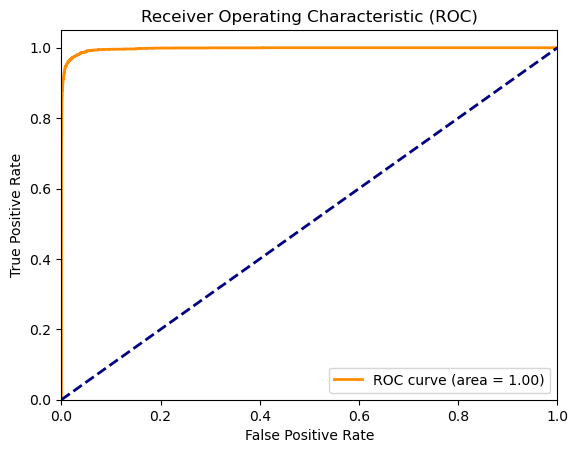

In [188]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer

# Calcular las probabilidades de clase y las probabilidades condicionales
class_probabilities = calculate_class_probabilities(y_train)
conditional_probabilities = calculate_conditional_probabilities(X_train, y_train)

# Obtener las probabilidades predichas para cada clase
y_pred_prob = [classify(x, class_probabilities, conditional_probabilities) for x in X_test]

# Convertir las probabilidades predichas en etiquetas
y_pred = [max(prob.keys(), key=lambda k: prob[k]) for prob in y_pred_prob]

# Convertir y_test y y_pred a formato binario para métricas
lb = LabelBinarizer()
lb.fit(y_train)  # Ajustar el binarizador con las etiquetas de entrenamiento
y_test_bin = lb.transform(y_test)
y_pred_bin = lb.transform(y_pred)

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test_bin.argmax(axis=1), y_pred_bin.argmax(axis=1))
print("Matriz de Confusión:")
print(conf_matrix)

# Calcular las medidas de evaluación
accuracy = accuracy_score(y_test_bin, y_pred_bin)
precision = precision_score(y_test_bin, y_pred_bin, average='weighted')
recall = recall_score(y_test_bin, y_pred_bin, average='weighted')
f1 = f1_score(y_test_bin, y_pred_bin, average='weighted')

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precisión: {precision:.2f}")
print(f"Tasa de Verdaderos Positivos (Recall): {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Calcular la curva ROC
y_test_bin_flat = y_test_bin.ravel()
y_pred_prob_flat = np.array([prob[c] for prob in y_pred_prob for c in lb.classes_])

fpr, tpr, _ = roc_curve(y_test_bin_flat, y_pred_prob_flat)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()
